In [59]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")




data = open('names.txt', 'r').read().splitlines()


clean = sorted(list(set(''.join(data))))

# Creating dictionaries for character-to-integer and integer-to-character mappings
char_to_int = {s: i + 1 for i, s in enumerate(clean)}
char_to_int['.'] = 0  # Add the end token
int_to_char = {i: s for s, i in char_to_int.items()}

x, y = [], []



In [60]:
# Collect inputs from user for block size
block_size = int(input("Enter the block size: "))


for datum in data[:10]:  # Limiting to first 5 names for example purposes
    print(datum)
    context = [0] * block_size  # Initialize context with zeros
    for ch in datum + '.':  # Append the end token
        ix = char_to_int[ch]
        x.append(context)
        y.append(ix)
        print("".join(int_to_char[i] for i in context), '----->', int_to_char[ix])
        context = context[1:] + [ix]  # Shift context

x = torch.tensor(x)
y = torch.tensor(y)

# Random number generator for reproducibility
g = torch.Generator().manual_seed(213456789)

# Initialize parameters
w1 = torch.randn((block_size * 2, 100), generator=g)  # Adjusted input dimension
b1 = torch.randn(100, generator=g)
w2 = torch.randn((100, len(char_to_int)), generator=g)
b2 = torch.randn(len(char_to_int), generator=g)
c = torch.rand((len(char_to_int), 2), generator=g)  # Embedding matrix
parameters = [c, w1, b1, w2, b2]



Enter the block size: 15
emma
............... -----> e
..............e -----> m
.............em -----> m
............emm -----> a
...........emma -----> .
olivia
............... -----> o
..............o -----> l
.............ol -----> i
............oli -----> v
...........oliv -----> i
..........olivi -----> a
.........olivia -----> .
ava
............... -----> a
..............a -----> v
.............av -----> a
............ava -----> .
isabella
............... -----> i
..............i -----> s
.............is -----> a
............isa -----> b
...........isab -----> e
..........isabe -----> l
.........isabel -----> l
........isabell -----> a
.......isabella -----> .
sophia
............... -----> s
..............s -----> o
.............so -----> p
............sop -----> h
...........soph -----> i
..........sophi -----> a
.........sophia -----> .
charlotte
............... -----> c
..............c -----> h
.............ch -----> a
............cha -----> r
...........char -----> l
........

In [67]:
for p in parameters:
    p.requires_grad = True

# Learning rate schedule
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

# Training loop
lri = []
lossi = []

for i in range(1000):
    ix = torch.randint(0, x.shape[0], (32,))  # Random mini-batch
    emb = c[x[ix]]  # Embedding lookup
    new = emb.view(emb.shape[0], -1)  # Flatten embedding
    h = torch.tanh(new @ w1 + b1)  # First layer
    logit = h @ w2 + b2  # Output layer
    loss = F.cross_entropy(logit, y[ix])  # Compute loss
    print(loss.item())
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad  # Update parameters

    lossi.append(loss.item())
    lri.append(lr)

1.4545296430587769
1.152327537536621
0.9223329424858093
1.2313497066497803
0.29942673444747925
0.6364023685455322
1.0873539447784424
1.4527838230133057
0.6315833330154419
1.243074655532837
1.3223952054977417
0.9233353734016418
2.219184637069702
1.5379652976989746
1.1440846920013428
0.7805659174919128
2.4623327255249023
1.4782134294509888
1.2799468040466309
1.272640347480774
0.6036943793296814
3.403911590576172
1.364943265914917
0.8224225640296936
0.6845221519470215
0.8801996111869812
1.1318271160125732
0.45230257511138916
0.8199666142463684
1.499528408050537
1.9604222774505615
0.7409904599189758
1.793959379196167
0.5437560081481934
0.4465855062007904
0.2518409788608551
0.40043017268180847
0.42073336243629456
0.45431452989578247
1.1192806959152222
1.3380520343780518
0.9552193284034729
0.6407737731933594
0.8366674184799194
1.2248364686965942
1.1056121587753296
0.739622950553894
1.3969701528549194
0.7328704595565796
1.6633028984069824
0.845670223236084
0.8383759260177612
1.084098100662231

0.3050518035888672
0.14893455803394318
0.38361915946006775
0.39390283823013306
0.3193054497241974
0.47082385420799255
0.453393816947937
0.45757579803466797
0.26785653829574585
0.43850940465927124
0.10140467435121536
0.4386384189128876
0.5085376501083374
0.19170662760734558
0.262897253036499
0.33372536301612854
0.22341148555278778
0.33182695508003235
0.20736929774284363
0.4766829013824463
0.360175758600235
0.48003673553466797
0.3817838430404663
0.3685297966003418
0.48616549372673035
0.11118369549512863
0.32157063484191895
0.3035326898097992
0.6384479403495789
0.2785092294216156
0.2402656078338623
0.2591850459575653
0.28452831506729126
0.4100709557533264
0.49002334475517273
0.371401846408844
0.5752618908882141
0.34806564450263977
0.41458189487457275
0.3226924538612366
0.20394787192344666
0.5125067830085754
0.1609450727701187
0.2094694823026657
0.6044893264770508
0.27696001529693604
0.4261837303638458
0.3677496910095215
0.2652147710323334
0.412538081407547
0.2035617232322693
0.24075454473

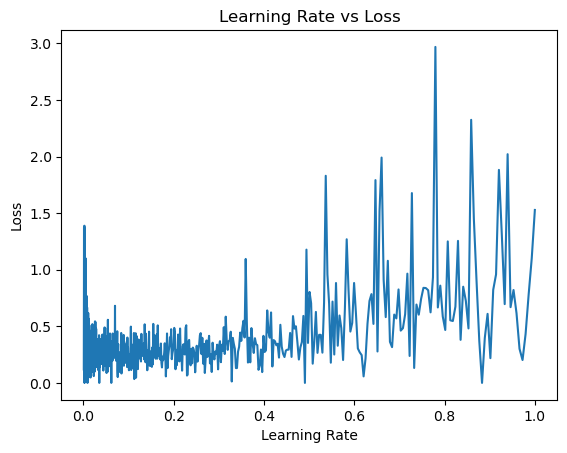

In [5]:
# Plotting the loss
plt.plot(lri, lossi)
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('Learning Rate vs Loss')
plt.show()


In [110]:
def generate_name(block_size, max_length=15):
    context = [0] * block_size  
    name = [ ]
    while True:
        emb = c[torch.tensor(context).unsqueeze(-1)]
        new = emb.view(1, -1)
        h = torch.tanh(new @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0 or len(name) >= max_length:
            break
        name.append(int_to_char[ix])
        context = context[1:] + [ix]
    return ''.join(name)


for _ in range(13):
    print(generate_name(block_size))

evelyn
sophia
eeeeevesyelia
evelyn
evelyn
evelyn
evelyn
evelyn
evelyn
eeeeevelyn
evelyn
evelyn
evelyn
